In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:1024"

In [2]:
import torch
import torch.nn as nn

import numpy as np

from scipy.interpolate import griddata

import matplotlib.pyplot as plt


# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('CUDA')
else:
    device = torch.device('cpu')
    print('CPU')

CUDA


In [3]:
from matplotlib import colors
import matplotlib.ticker as mticker

def plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)

    # Set colormap
    cmap = 'jet'
    datasets = [u, u_pr, np.abs(u-u_pr)]
    norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))

    # Subplot a)
    im1 = axes[0, 0].imshow(u, extent=[xmin, xmax, ymin, ymax], cmap=cmap, norm=norm)
    axes[0, 0].set_title("a) predicted solution")
    axes[0, 0].set_xlabel("x")
    axes[0, 0].set_ylabel("y")
    axes[0, 0].set_xticks([0, np.pi/2, np.pi])
    axes[0, 0].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 0].set_yticks([0, np.pi/2, np.pi])
    axes[0, 0].set_yticklabels(['0', 'π/2', 'π'])

    # Subplot b)
    im2 = axes[0, 1].imshow(u_pr, extent=[xmin, xmax, ymin, ymax], cmap=cmap, norm=norm)
    axes[0, 1].set_title("b) precise solution")
    axes[0, 1].set_xticks([0, np.pi/2, np.pi])
    axes[0, 1].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 1].set_yticks([0, np.pi/2, np.pi])
    axes[0, 1].set_yticklabels(['0', 'π/2', 'π'])
    axes[0, 1].set_xlabel("x")
    axes[0, 1].set_ylabel("y")

    # Subplot c)
    im3 = axes[0, 2].imshow(np.abs(u_pr-u), extent=[xmin, xmax, ymin, ymax], cmap=cmap)
    axes[0, 2].set_title("c) difference")
    axes[0, 2].set_xticks([0, np.pi/2, np.pi])
    axes[0, 2].set_xticklabels(['0', 'π/2', 'π'])
    axes[0, 2].set_yticks([0, np.pi/2, np.pi])
    axes[0, 2].set_yticklabels(['0', 'π/2', 'π'])
    axes[0, 2].set_xlabel("x")
    axes[0, 2].set_ylabel("y")

    #colorbar for a), b)
    cbar1 = fig.colorbar(im2, ax=[axes[0, 0], axes[0, 1]],
                          pad=0.04, location='right', fraction = 0.022, ticks = mticker.LinearLocator(numticks = 5 ))
    #colorbar for c)
    cbar2 = fig.colorbar(im3, ax=[axes[0, 2]],
                          pad=0.04, location='right', fraction = 0.053, ticks = mticker.LinearLocator(numticks = 5 ))

    # Subplot d)
    y1 = np.linspace(ymin, ymax, Ny_points)
    #x = 0
    im4 = axes[1, 0].plot(y1, u[:, 0], '--', label = 'pred')
    axes[1, 0].plot(y1, u_pr[:, 0], label = 'true')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].set_title("d) x = x_min")
    axes[1, 0].set_xticks([0, np.pi/2, np.pi])
    axes[1, 0].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 0].set_xlabel("y")
    axes[1, 0].set_ylabel("u")

    # Subplot e)
    #x = pi/2
    im5 = axes[1, 1].plot(y1, u[:, Nx_points//2-1], '--', label = 'pred')
    axes[1, 1].plot(y1, u_pr[:, Nx_points//2-1], label = 'true')
    axes[1, 1].legend(loc='upper right')
    axes[1, 1].set_title("e) x = (x_min + x_max)/2")
    axes[1, 1].set_xticks([0, np.pi/2, np.pi])
    axes[1, 1].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 1].set_xlabel("y")
    axes[1, 1].set_ylabel("u")

    # Subplot f)
    #x = pi
    im6 = axes[1, 2].plot(y1, u[:, Nx_points-1], '--', label = 'pred')
    axes[1, 2].plot(y1, u_pr[:, Nx_points-1], label = 'true')
    axes[1, 2].legend(loc='upper right')
    axes[1, 2].set_title("f) x = x_max")
    axes[1, 2].set_xticks([0, np.pi/2, np.pi])
    axes[1, 2].set_xticklabels(['0', 'π/2', 'π'])
    axes[1, 2].set_xlabel("y")
    axes[1, 2].set_ylabel("u")

In [4]:
import imageio.v2 as imageio

def save_movie(training_frames, N_frames, xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename="movie.gif", fps=1):
    #norm = colors.Normalize(vmin=np.min(training_frames), vmax=np.max(training_frames))
    with imageio.get_writer(filename, mode='I', fps=fps) as writer:
        for i in range(N_frames):
            fig = plt.figure(figsize=(4, 4))
            im = plt.imshow(training_frames[i:i+1, :].reshape(Nx_points, Ny_points, order = 'F'), extent=[xmin, xmax, ymin, ymax], cmap='jet')
            fig.colorbar(im, pad=0.04, location='right', fraction = 0.046, ticks = mticker.LinearLocator(numticks = 5 ))
            plt.title(f'Frame {i + 1}, iter {(i + 1) * 200}')
            plt.xlabel("x")
            plt.ylabel("y")
            plt.xticks(ticks = [0, np.pi/2, np.pi], labels = ['0', 'π/2', 'π'])
            #plt.xticklabels(['0', 'π/2', 'π'])
            plt.yticks(ticks = [0, np.pi/2, np.pi], labels = ['0', 'π/2', 'π'])
            #plt.yticklabels(['0', 'π/2', 'π'])
            # Save the plot to a temporary image
            plt.savefig('temp_plot.png', dpi=fig.dpi)
            writer.append_data(imageio.imread('temp_plot.png'))
            plt.close()  # Close the plot to avoid displaying it in interactive environments

    print(f"Movie saved as {filename}")

In [5]:
class Sampler:
    # Initialize the class
    def __init__(self, dim, coords, func, name = None):
        self.dim = dim
        self.coords = coords
        self.func = func
        self.name = name
    def sample(self, N, mu_flag = False, mu_X = 0, sigma_X = 1):
        x = self.coords[0:1,:] + (self.coords[1:2,:]-self.coords[0:1,:])*np.random.rand(N, self.dim)
        if mu_flag:
          x = (x - mu_X) / sigma_X
        y = self.func(x)
        return x, y


In [6]:
# Creating Neural Network
class NN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super(NN, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        # initialize weight and Biases
        nn.init.xavier_uniform_(self.l1.weight)
        self.l1.bias.data.fill_(0.0)

        self.tanh = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l2.bias.data.fill_(0.0)
        nn.init.xavier_uniform_(self.l2.weight)

        self.l3 = nn.Linear(hidden_size, hidden_size)
        self.l3.bias.data.fill_(0.0)
        nn.init.xavier_uniform_(self.l3.weight)

        self.l4 = nn.Linear(hidden_size, output_size)
        nn.init.xavier_uniform_(self.l4.weight)
        self.l4.bias.data.fill_(0.0)

    def forward(self, x):
        out = self.l1(x)
        out = self.tanh(out)
        out = self.l2(out)
        out = self.tanh(out)
        out = self.l3(out)
        out = self.tanh(out)
        out = self.l4(out)
        return out

In [7]:
class PINN:
    # Initialize the class
    #def __init__(self, layers, operator, bcs_sampler, res_sampler, c, kernel_size):
    def __init__(self, layers, operator, bcs_sampler, res_sampler, a, b, kernel_size):

        # Normalization
        X, _ = res_sampler.sample(np.int32(1e5))
        self.mu_X, self.sigma_X = X.mean(0), X.std(0)
        self.mu_y, self.sigma_y = self.mu_X[1], self.sigma_X[1]
        self.mu_x, self.sigma_x = self.mu_X[0], self.sigma_X[0]

        # Samplers
        self.operator = operator
        #self.ics_sampler = ics_sampler
        self.bcs_sampler = bcs_sampler
        self.res_sampler = res_sampler

        # weights
        self.lam_u_val = torch.tensor(1.0).float().to(device)
        #self.lam_ut_val = torch.tensor(1.0).float().to(device)
        self.lam_r_val = torch.tensor(1.0).float().to(device)

        # Wave constant
        #self.c = torch.tensor(c).float().to(device)
        self.a = torch.tensor(a).float().to(device)
        self.b = torch.tensor(b).float().to(device)

        self.kernel_size = kernel_size # Size of the NTK matrix

        self.D1 = self.kernel_size    # boundary
        # self.D2 = self.kernel_size    # ut
        self.D3 = self.kernel_size    # residual  D1 = D3 = 3D2

        # Neural Network
        self.nn = NN(layers[0], layers[1], layers[-1]).to(device)

        self.optimizer_Adam = torch.optim.Adam(params=self.nn.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
        self.my_lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer=self.optimizer_Adam, gamma=0.9)

        # Logger
        self.loss_bcs_log = []
        #self.loss_ut_ics_log = []
        self.loss_res_log = []
        self.l2_res_log = []

        # NTK logger
        self.K_u_log = []
        #self.K_ut_log = []
        self.K_r_log = []

        # weights logger
        self.lam_u_log = []
        #self.lam_ut_log = []
        self.lam_r_log = []

    # Forward pass for u
    def net_u(self, x, y):
      if x.dim()==0:
            x = x.reshape(1)
            y = y.reshape(1)
            u = self.nn(torch.cat([x, y], dim=0))
      else:
            u = self.nn(torch.cat([x, y], dim=1))
      return u

    # Forward pass for the residual
    def net_r(self, x, y):
        u = self.net_u(x, y)
        residual = self.operator(u, x, y,
                                 self.a,
                                 self.b,
                                 self.sigma_x,
                                 self.sigma_y)
        return residual

    # Gradient operation
    def gradient(self, y, x, grad_outputs=None):
        if grad_outputs is None:
            grad_outputs = torch.ones_like(y)
        grad = torch.autograd.grad(y, [x], grad_outputs = grad_outputs, create_graph=True, allow_unused=True)[0]
        return grad

    # Compute Jacobian for each weights and biases in each layer and return a list
    def compute_jacobian(self, output, params):
        output = output.reshape(-1)
        J_dum = []
        J_List = []

        for i in range(len(params)):
            grad, = torch.autograd.grad(output, params[i], (torch.eye(output.shape[0]).to(device),),retain_graph=True, allow_unused=True, is_grads_batched=True)
            if grad == None:
                pass
            else:
                J_dum.append(grad)

                if np.mod(i,2)==1:
                    if grad == None:
                        pass
                    J_List.append(torch.cat((J_dum[i-1].flatten().reshape(len(output),-1),grad.flatten().reshape(len(output),-1)), 1))
        return J_List

    # Compute Neural Tangent Kernel's Trace Values
    def compute_ntk(self, J1, d1, J2, d2):

        Ker = torch.zeros((d1,d2)).float().to(device)

        for i in range(len(J1)):
            K = torch.matmul(J1[i], J2[i].t())
            Ker = Ker + K
        return Ker


    def fetch_minibatch(self, sampler, N, mu_flag = False):
        X, Y = sampler.sample(N, mu_flag, self.mu_x, self.sigma_X)
        #X = (X - self.mu_X) / self.sigma_X
        return X, Y

    # Trains the model by minimizing the MSE loss
    #def train(self, nIter=10000, batch_size=128, log_NTK=False, update_lam=False):
    def train(self, X_star, nIter=10000, batch_size=128, log_NTK=False, update_lam=False, call_save_movie = False, fps = 1):

        # NTK
        self.nn.train()

        training_frames = np.empty((0, X_star.shape[0]))

        for it in range(nIter):
            # Fetch boundary mini-batches
            #X_ics_batch, u_ics_batch = self.fetch_minibatch(self.ics_sampler, batch_size // 3)
            X_bc1_batch, u_bc1_batch = self.fetch_minibatch(self.bcs_sampler[0], batch_size // 4) #, mu_flag = True)
            X_bc2_batch, u_bc2_batch = self.fetch_minibatch(self.bcs_sampler[1], batch_size // 4)#, mu_flag = True)
            X_bc3_batch, u_bc3_batch = self.fetch_minibatch(self.bcs_sampler[2], batch_size // 4)#, mu_flag = True)
            X_bc4_batch, u_bc4_batch = self.fetch_minibatch(self.bcs_sampler[3], batch_size // 4)#, mu_flag = True)

            # Tensor
            #X_ics_batch_tens = torch.tensor(X_ics_batch, requires_grad=True).float().to(device)
            #u_ics_batch_tens = torch.tensor(u_ics_batch, requires_grad=True).float().to(device)
            X_bc1_batch_tens = torch.tensor(X_bc1_batch, requires_grad=True).float().to(device)
            u_bc1_batch_tens = torch.tensor(u_bc1_batch, requires_grad=True).float().to(device)
            X_bc2_batch_tens = torch.tensor(X_bc2_batch, requires_grad=True).float().to(device)
            u_bc2_batch_tens = torch.tensor(u_bc2_batch, requires_grad=True).float().to(device)
            X_bc3_batch_tens = torch.tensor(X_bc3_batch, requires_grad=True).float().to(device)
            u_bc3_batch_tens = torch.tensor(u_bc3_batch, requires_grad=True).float().to(device)
            X_bc4_batch_tens = torch.tensor(X_bc4_batch, requires_grad=True).float().to(device)
            u_bc4_batch_tens = torch.tensor(u_bc4_batch, requires_grad=True).float().to(device)

            # Fetch residual mini-batch
            X_res_batch, _ = self.fetch_minibatch(self.res_sampler, batch_size)#, mu_flag = True)
            X_res_batch_tens = torch.tensor(X_res_batch, requires_grad=True).float().to(device)

            #u_pred_ics = self.net_u(X_ics_batch_tens[:, 0:1], X_ics_batch_tens[:, 1:2])
            #u_t_pred_ics = self.net_u_t(X_ics_batch_tens[:, 0:1], X_ics_batch_tens[:, 1:2])
            u_pred_bc1 = self.net_u(X_bc1_batch_tens[:, 0:1], X_bc1_batch_tens[:, 1:2])
            u_pred_bc2 = self.net_u(X_bc2_batch_tens[:, 0:1], X_bc2_batch_tens[:, 1:2])
            u_pred_bc3 = self.net_u(X_bc3_batch_tens[:, 0:1], X_bc3_batch_tens[:, 1:2])
            u_pred_bc4 = self.net_u(X_bc4_batch_tens[:, 0:1], X_bc4_batch_tens[:, 1:2])
            r_pred = self.net_r(X_res_batch_tens[:, 0:1], X_res_batch_tens[:, 1:2])
            f_r_tens = f_right_tensor(X_res_batch_tens, self.a, self.b)

            #loss_bcs = torch.mean((u_ics_batch_tens - u_pred_ics) ** 2) + torch.mean(u_pred_bc1 ** 2) + torch.mean(u_pred_bc2 ** 2)
            #loss_bcs = torch.mean(u_pred_bc1 ** 2) + torch.mean(u_pred_bc2 ** 2) + torch.mean(u_pred_bc3 ** 2) + torch.mean(u_pred_bc4 ** 2)
            loss_bcs = torch.mean((u_pred_bc1 - u_bc1_batch_tens) ** 2) + torch.mean((u_pred_bc2 - u_bc2_batch_tens) ** 2) + \
                                          torch.mean((u_pred_bc3 - u_bc3_batch_tens) ** 2) + torch.mean((u_pred_bc4 - u_bc4_batch_tens) ** 2)
            #loss_ics_u_t = torch.mean(u_t_pred_ics ** 2)
            loss_res = torch.mean(r_pred ** 2)
            l2_res = torch.norm(r_pred, p = 2)/torch.norm(f_r_tens, p = 2)

            #loss = self.lam_r_val * loss_res + self.lam_u_val * loss_bcs + self.lam_ut_val * loss_ics_u_t
            loss = self.lam_r_val * loss_res + self.lam_u_val * loss_bcs

            # Backward and optimize
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()

            if call_save_movie and X_star.shape[0] != 0:
               if it % 200 == 0:
                  u_pred_for_frames = self.predict_u(X_star).T
                  training_frames = np.concatenate((training_frames, u_pred_for_frames), axis=0)

            if it % 1000 == 0:
                self.my_lr_scheduler.step()

            # Print
            if it % 100 == 0:

                # Store losses
                self.loss_bcs_log.append(loss_bcs.detach().cpu().numpy())
                self.loss_res_log.append(loss_res.detach().cpu().numpy())
                self.l2_res_log.append(l2_res.detach().cpu().numpy())
                #self.loss_ut_ics_log.append(loss_ics_u_t.detach().cpu().numpy())

                # print('It: %d, Loss: %.3e, Loss_res: %.3e,  Loss_bcs: %.3e, Loss_ut_ics: %.3e' %
                #       (it, loss.item(), loss_res, loss_bcs, loss_ics_u_t))

                print('It: %d, Loss: %.3e, Loss_res: %.3e,  Loss_bcs: %.3e, l2_res: %.3e' %
                      (it, loss.item(), loss_res, loss_bcs, l2_res))

                print(f'lambda_u: {self.lam_u_val:3e}')
                #print(f'lambda_ut: {self.lam_ut_val:3e}')
                print(f'lambda_r: {self.lam_r_val:3e}')

            if log_NTK:

                if it % 100 == 0:
                    print("Compute NTK...")
                    X_bc_batch = np.vstack([X_bc1_batch, X_bc2_batch, X_bc3_batch, X_bc4_batch])
                    #X_bc_batch = np.vstack([X_bc1_batch, X_bc2_batch, X_bc3_batch])

                    # Convert to the tensor
                    X_bc_batch_tens = torch.tensor(X_bc_batch, requires_grad=True).float().to(device)

                    # Get the parameters of NN
                    params = list(self.nn.parameters())

                    # Store the trace
                    K_u_value = 0
                    #K_ut_value = 0
                    K_r_value = 0

                    u_ntk_pred = self.net_u(X_bc_batch_tens[:,0:1], X_bc_batch_tens[:,1:2])
                    #u_t_ntk_pred = self.net_u_t(X_ics_batch_tens[:,0:1], X_ics_batch_tens[:,1:2])
                    r_ntk_pred = self.net_r(X_res_batch_tens[:,0:1], X_res_batch_tens[:,1:2])

                    # Jacobian of the neural networks
                    J_u = self.compute_jacobian(u_ntk_pred, params)
                    #J_ut = self.compute_jacobian(u_t_ntk_pred, params)
                    J_r = self.compute_jacobian(r_ntk_pred, params)

                    #print(f'J_u shape: {J_u.shape}, J_r shape: {J_r.shape}')

                    # Neural tangent kernels of the neural networks / Trace values
                    K_u_value = self.compute_ntk(J_u, self.D1, J_u, self.D1)
                    #K_ut_value = self.compute_ntk(J_ut, self.D2, J_ut, self.D2)
                    K_r_value = self.compute_ntk(J_r, self.D3, J_r, self.D3)

                    # Convert tensor to numpy array
                    K_u_value = K_u_value.detach().cpu().numpy()
                    #K_ut_value = K_ut_value.detach().cpu().numpy()
                    K_r_value = K_r_value.detach().cpu().numpy()

                    #trace_K = np.trace(K_u_value) + np.trace(K_ut_value) + np.trace(K_r_value)
                    trace_K = np.trace(K_u_value) + np.trace(K_r_value)

                    # Store Trace values
                    self.K_u_log.append(K_u_value)
                    #self.K_ut_log.append(K_ut_value)
                    self.K_r_log.append(K_r_value)

                    if update_lam:

                        self.lam_u_val = trace_K / np.trace(K_u_value)
                        #self.lam_ut_val = trace_K / np.trace(K_ut_value)
                        self.lam_r_val = trace_K / np.trace(K_r_value)

                        # Store NTK weights
                        self.lam_u_log.append(self.lam_u_val)
                        #self.lam_ut_log.append(self.lam_ut_val)
                        self.lam_r_log.append(self.lam_r_val)

        if call_save_movie:
          file_name = "p2_movie_" + str(a) + '_' + str(b) + ".gif"
          save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, fps=fps)
        return training_frames

    # Evaluates predictions at test points
    def predict_u(self, X_star):
        #X_star = (X_star - self.mu_X) / self.sigma_X

        y = torch.tensor(X_star[:, 1:2], requires_grad=True).float().to(device)
        x = torch.tensor(X_star[:, 0:1], requires_grad=True).float().to(device)

        self.nn.eval()

        #u_star = self.net_u(t, x)
        u_star = self.net_u(x, y)
        u_star = u_star.detach().cpu().numpy()
        return u_star

    # Evaluates predictions at test points
    def predict_r(self, X_star):
        #X_star = (X_star - self.mu_X) / self.sigma_X

        x = torch.tensor(X_star[:, 0:1], requires_grad=True).float().to(device)
        y = torch.tensor(X_star[:, 1:2], requires_grad=True).float().to(device)

        self.nn.eval()

        #r_star = self.net_r(t, x)
        r_star = self.net_r(x, y)
        r_star = r_star.detach().cpu().numpy()
        return r_star

In [8]:
# Define the exact solution and its derivatives
def u_precise(x, a, b):
    y = x[:,1:2]
    x = x[:,0:1]
    return np.sin(a*x) * np.cos(b*y)

#boundary condition
def g(x, a, b):
    y = x[:,1:2]
    x = x[:,0:1]
    return np.sin(a*x) * np.cos(b*y)

def f_right_tensor(x, a, b):
    f = (a**2 + b**2)*torch.sin(a*x[:, 0:1])*torch.cos(b*x[:, 1:2])
    return  f

def f_right(x, a, b):
    f = (a**2 + b**2)*np.sin(a*x[:, 0:1])*np.cos(b*x[:, 1:2])
    return  f

#def operator(u, t, x, c, sigma_t=1.0, sigma_x=1.0):
def operator(u, x, y, a, b, sigma_x=1.0, sigma_y=1.0):
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True
    )[0] / sigma_x

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        retain_graph=True,
        create_graph=True
    )[0] / sigma_x

    u_y = torch.autograd.grad(
        u, y,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=True
    )[0] / sigma_y

    u_yy = torch.autograd.grad(
        u_y, y,
        grad_outputs=torch.ones_like(u_y),
        retain_graph=True,
        create_graph=True
    )[0] / sigma_y

    residual = (a**2 + b**2)*torch.sin(a*x)*torch.cos(b*y) + u_xx + u_yy
    return residual

In [9]:
def predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=False, fps = 1):
      # Domain boundaries
      dom_coords = np.array([[xmin, ymin],
                              [xmax, ymax]])

      # Create boundary conditions samplers (e.g., Dirichlet boundaries)
      bc1_coords = np.array([[xmin, ymin], [xmin, ymax]])  # left edge
      bc2_coords = np.array([[xmax, ymin], [xmax, ymax]])  # right edge
      bc3_coords = np.array([[xmin, ymin], [xmax, ymin]])  # bottom edge
      bc4_coords = np.array([[xmin, ymax], [xmax, ymax]])  # top edge

      bc1 = Sampler(2, bc1_coords, lambda x: g(x, a, b), name='Dirichlet BC1')
      bc2 = Sampler(2, bc2_coords, lambda x: g(x, a, b), name='Dirichlet BC2')
      bc3 = Sampler(2, bc3_coords, lambda x: g(x, a, b), name='Dirichlet BC3')
      bc4 = Sampler(2, bc4_coords, lambda x: g(x, a, b), name='Dirichlet BC4')
      bcs_sampler = [bc1, bc2, bc3, bc4]

      # Create residual sampler
      res_sampler = Sampler(2, dom_coords, lambda x: 0, name='Forcing')

      # Define PINN model
      layers = [2, 500, 500, 500, 1]
      kernel_size = 400
      model = PINN(layers, operator, bcs_sampler, res_sampler, a, b, kernel_size)

      # Train model
      log_NTK = False # Compute and store NTK matrix during training
      update_lam = True # Compute and update the loss weights using the NTK

      x = np.linspace(dom_coords[0, 0], dom_coords[1, 0], Nx_points)[:, None]
      y = np.linspace(dom_coords[0, 1], dom_coords[1, 1], Ny_points)[:, None]
      x, y = np.meshgrid(x, y)
      X_star = np.vstack([x.ravel(order = 'F'), y.ravel(order = 'F')]).T
      #X_star = np.hstack((x.flatten()[:, None], y.flatten()[:, None]))

      #model.train(nIter=itertaions, batch_size=kernel_size, log_NTK=log_NTK, update_lam=update_lam)
      training_frames = model.train(X_star, nIter=N_iter, batch_size=kernel_size, log_NTK=log_NTK, update_lam=update_lam, call_save_movie = call_save_movie, fps = fps)

      loss_res = model.loss_res_log
      loss_bcs = model.loss_bcs_log
      #loss_u_t_ics = model.loss_ut_ics_log

      fig = plt.figure(figsize=(6, 5))
      plt.plot(loss_res, label='$\mathcal{L}_{r}$')
      plt.plot(loss_bcs, label='$\mathcal{L}_{u}$')
      #plt.plot(loss_u_t_ics, label='$\mathcal{L}_{u_t}$')
      plt.yscale('log')
      plt.xlabel('iterations')
      plt.ylabel('Loss')
      plt.legend()
      plt.tight_layout()
      plt.show()

      u_star = u_precise(X_star, a, b).reshape(Nx_points, Ny_points, order='F')

      # Predictions
      u_pred = model.predict_u(X_star).reshape(Nx_points, Ny_points, order='F')
      residual = model.predict_r(X_star)
      error_u = np.linalg.norm(u_star - u_pred, 2) / np.linalg.norm(u_star, 2)
      error_c = np.max(np.abs(u_star - u_pred))
      residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))
      residual_c = np.max(residual)

      print("eps_l2 = ", error_u)
      print("eps_c = ",error_c)
      print("residual_l2 = ", residual_l2)
      print("residual_c = ", residual_c)

      #save uh in a file
      file_name = "uh_pinn_" + str(a) + '_' + str(b) + ".npy"
      np.save(file_name, u_pred)

      return u_pred, u_star, training_frames

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


It: 0, Loss: 1.946e+00, Loss_res: 1.023e+00,  Loss_bcs: 9.229e-01, l2_res: 9.975e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 100, Loss: 9.537e-01, Loss_res: 6.226e-01,  Loss_bcs: 3.311e-01, l2_res: 7.869e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 200, Loss: 5.779e-01, Loss_res: 3.152e-01,  Loss_bcs: 2.626e-01, l2_res: 5.450e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 300, Loss: 1.006e-01, Loss_res: 6.286e-02,  Loss_bcs: 3.772e-02, l2_res: 2.456e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 400, Loss: 5.427e-03, Loss_res: 4.250e-03,  Loss_bcs: 1.177e-03, l2_res: 6.359e-02
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 500, Loss: 2.060e-02, Loss_res: 3.073e-03,  Loss_bcs: 1.752e-02, l2_res: 5.519e-02
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 600, Loss: 2.423e-03, Loss_res: 2.114e-03,  Loss_bcs: 3.083e-04, l2_res: 4.742e-02
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 700, Loss: 6.236e-03, Loss_res: 2.021e-03,  Loss_bcs: 4.215e-03, l2

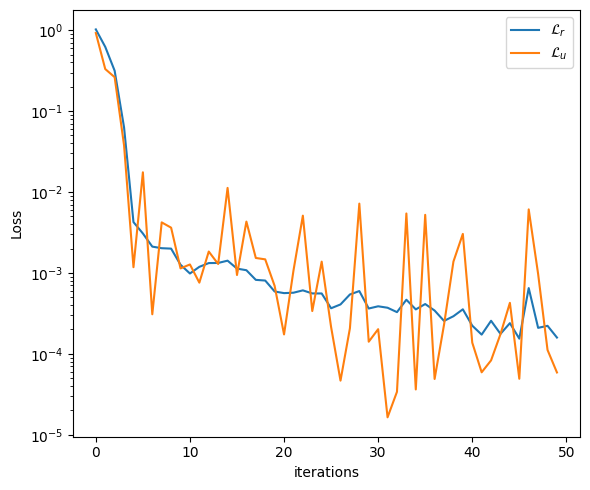

<ipython-input-9-7c647cf114ee>:61: RuntimeWarning: divide by zero encountered in scalar divide
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))


eps_l2 =  0.08485767735774016
eps_c =  0.07571050089292197
residual_l2 =  inf
residual_c =  0.111629225


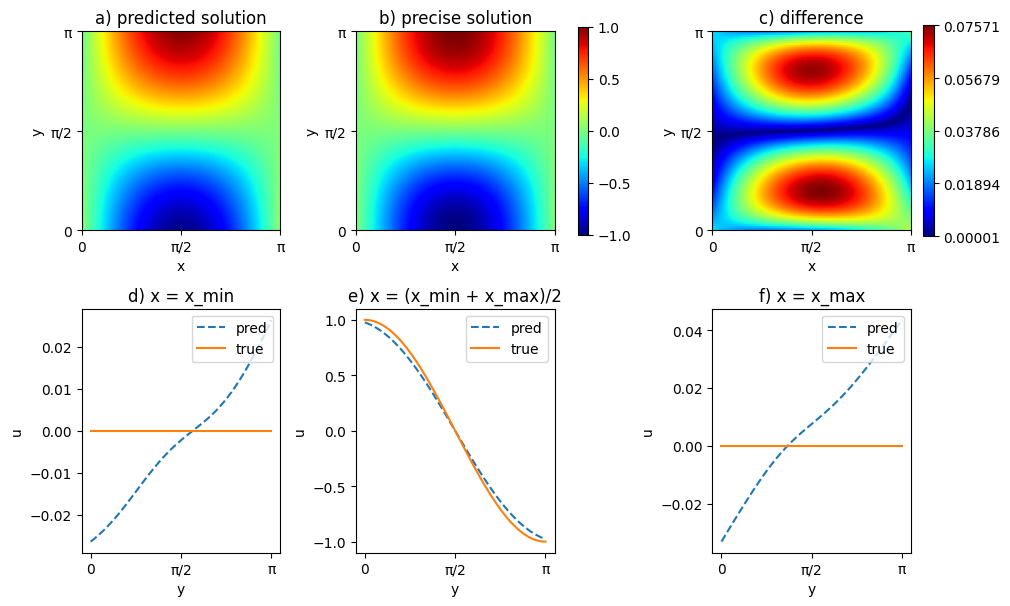

In [10]:
#frequencies of solution
a = 1
b = 1
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

It: 0, Loss: 2.352e+02, Loss_res: 2.338e+02,  Loss_bcs: 1.468e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 100, Loss: 2.180e+02, Loss_res: 2.172e+02,  Loss_bcs: 7.330e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 200, Loss: 2.180e+02, Loss_res: 2.174e+02,  Loss_bcs: 6.817e-01, l2_res: 9.988e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 300, Loss: 1.185e+02, Loss_res: 1.176e+02,  Loss_bcs: 8.995e-01, l2_res: 7.305e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 400, Loss: 3.142e+01, Loss_res: 3.078e+01,  Loss_bcs: 6.363e-01, l2_res: 3.785e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 500, Loss: 1.365e+00, Loss_res: 9.829e-01,  Loss_bcs: 3.825e-01, l2_res: 6.737e-02
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 600, Loss: 4.996e-01, Loss_res: 4.178e-01,  Loss_bcs: 8.180e-02, l2_res: 4.341e-02
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 700, Loss: 2.662e-01, Loss_res: 2.279e-01,  Loss_bcs: 3.829e-02, l2

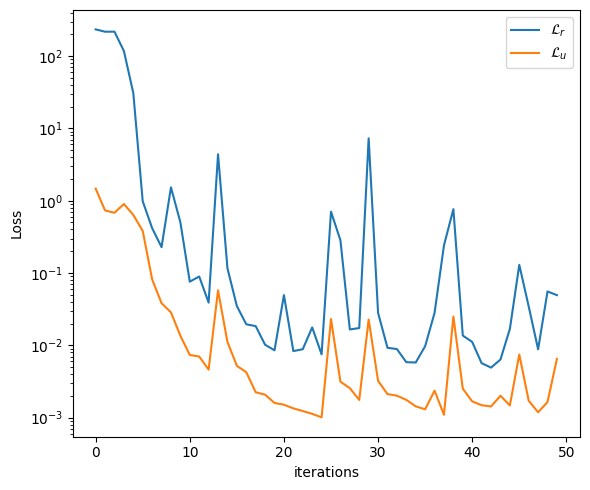

<ipython-input-9-06e93fb2e1f8>:61: RuntimeWarning: divide by zero encountered in scalar divide
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))


eps_l2 =  0.18818745623066638
eps_c =  0.24185373542435884
residual_l2 =  inf
residual_c =  1.4800035


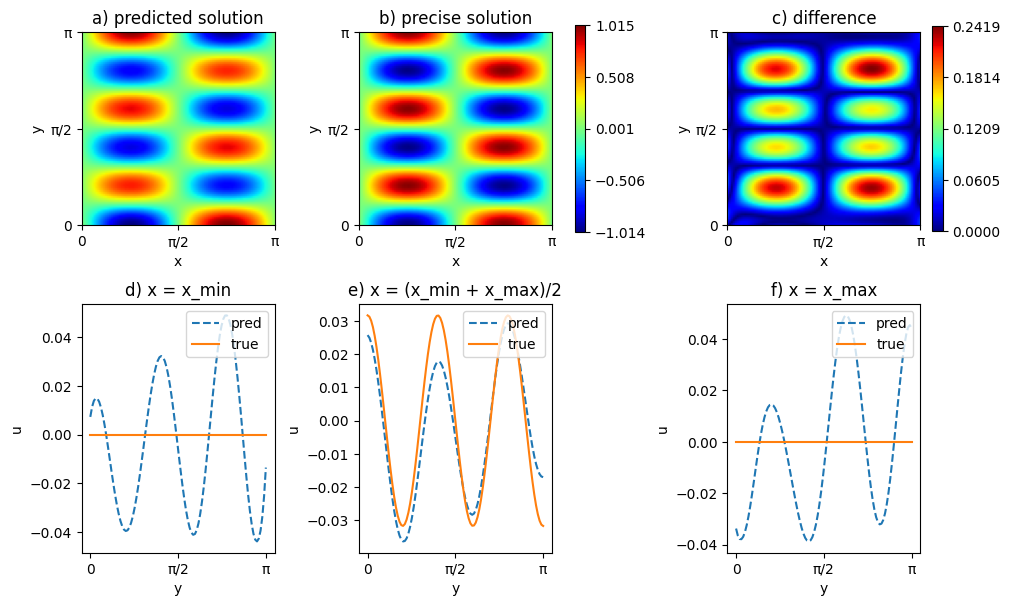

In [ ]:
#frequencies of solution
a = 2
b = 5
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

It: 0, Loss: 2.022e+03, Loss_res: 2.018e+03,  Loss_bcs: 3.428e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 100, Loss: 1.947e+03, Loss_res: 1.946e+03,  Loss_bcs: 9.459e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 200, Loss: 1.899e+03, Loss_res: 1.898e+03,  Loss_bcs: 9.075e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 300, Loss: 2.218e+03, Loss_res: 2.217e+03,  Loss_bcs: 9.797e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 400, Loss: 2.052e+03, Loss_res: 2.051e+03,  Loss_bcs: 9.582e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 500, Loss: 1.931e+03, Loss_res: 1.930e+03,  Loss_bcs: 9.650e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 600, Loss: 1.922e+03, Loss_res: 1.921e+03,  Loss_bcs: 9.586e-01, l2_res: 9.992e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 700, Loss: 2.148e+03, Loss_res: 2.147e+03,  Loss_bcs: 1.080e+00, l2

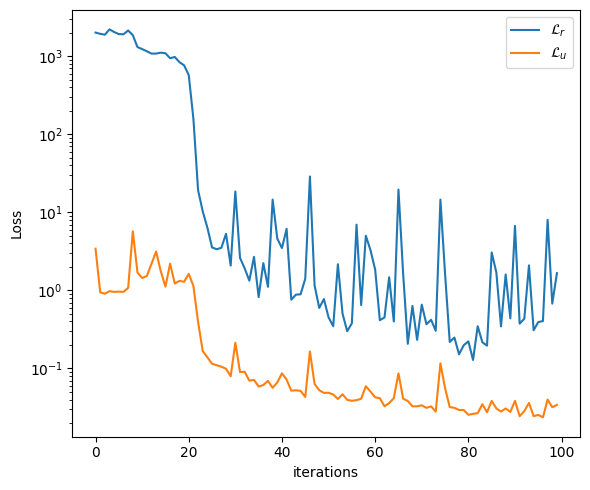

<ipython-input-9-7c647cf114ee>:61: RuntimeWarning: divide by zero encountered in scalar divide
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))


eps_l2 =  0.16976528846952835
eps_c =  0.2290823603913822
residual_l2 =  inf
residual_c =  1.997673


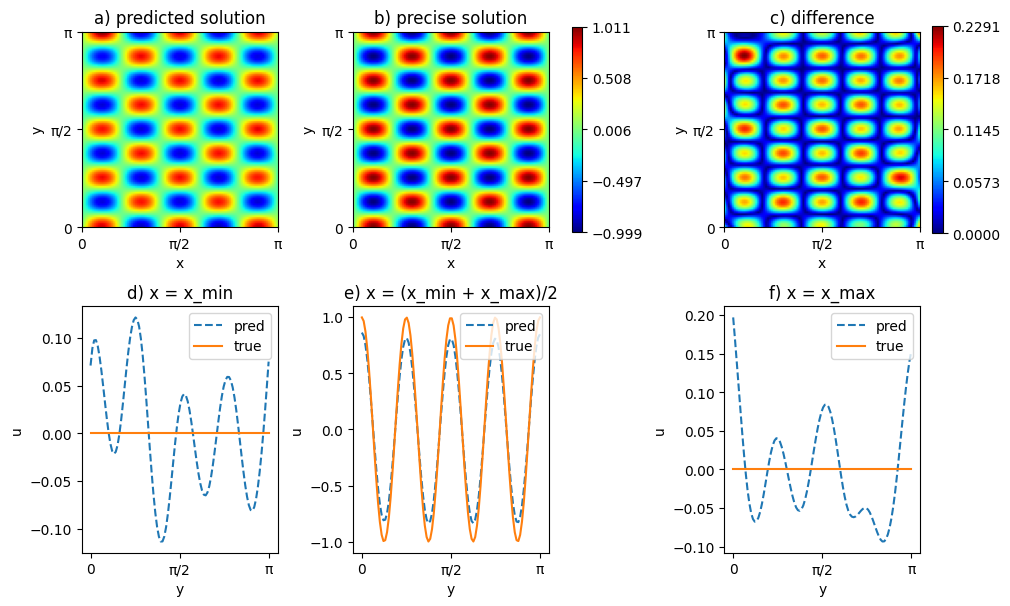

In [20]:
#frequencies of solution
a = 5
b = 8
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 10000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

It: 0, Loss: 3.912e+03, Loss_res: 3.911e+03,  Loss_bcs: 1.571e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 100, Loss: 3.851e+03, Loss_res: 3.851e+03,  Loss_bcs: 9.347e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 200, Loss: 4.311e+03, Loss_res: 4.310e+03,  Loss_bcs: 1.090e+00, l2_res: 9.981e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 300, Loss: 3.817e+03, Loss_res: 3.809e+03,  Loss_bcs: 7.947e+00, l2_res: 9.942e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 400, Loss: 3.228e+03, Loss_res: 3.226e+03,  Loss_bcs: 2.218e+00, l2_res: 9.381e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 500, Loss: 3.078e+03, Loss_res: 3.076e+03,  Loss_bcs: 1.352e+00, l2_res: 8.900e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 600, Loss: 3.143e+03, Loss_res: 3.142e+03,  Loss_bcs: 1.212e+00, l2_res: 8.452e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 700, Loss: 2.918e+03, Loss_res: 2.917e+03,  Loss_bcs: 1.223e+00, l2

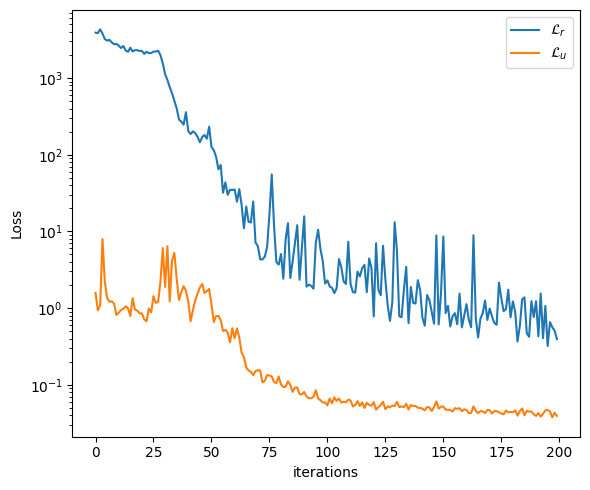

<ipython-input-9-7c647cf114ee>:61: RuntimeWarning: divide by zero encountered in scalar divide
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))


eps_l2 =  0.1739332724602737
eps_c =  0.2688027558790054
residual_l2 =  inf
residual_c =  4.831805


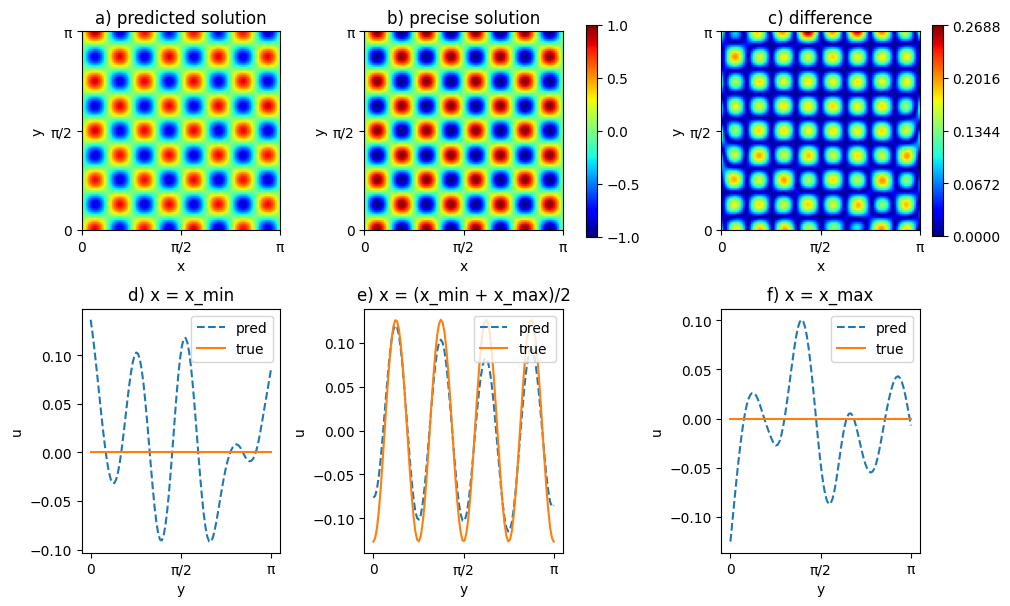

In [19]:
#frequencies of solution
a = 8
b = 8
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 20000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

It: 0, Loss: 5.176e+04, Loss_res: 5.176e+04,  Loss_bcs: 1.217e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 100, Loss: 5.139e+04, Loss_res: 5.139e+04,  Loss_bcs: 2.506e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 200, Loss: 5.296e+04, Loss_res: 5.295e+04,  Loss_bcs: 5.581e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 300, Loss: 5.644e+04, Loss_res: 5.644e+04,  Loss_bcs: 1.634e+00, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 400, Loss: 4.889e+04, Loss_res: 4.889e+04,  Loss_bcs: 1.308e+00, l2_res: 9.999e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 500, Loss: 5.021e+04, Loss_res: 5.021e+04,  Loss_bcs: 1.196e+00, l2_res: 9.995e-01
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 600, Loss: 5.113e+04, Loss_res: 5.113e+04,  Loss_bcs: 9.400e-01, l2_res: 1.000e+00
lambda_u: 1.000000e+00
lambda_r: 1.000000e+00
It: 700, Loss: 4.725e+04, Loss_res: 4.725e+04,  Loss_bcs: 1.139e+00, l2

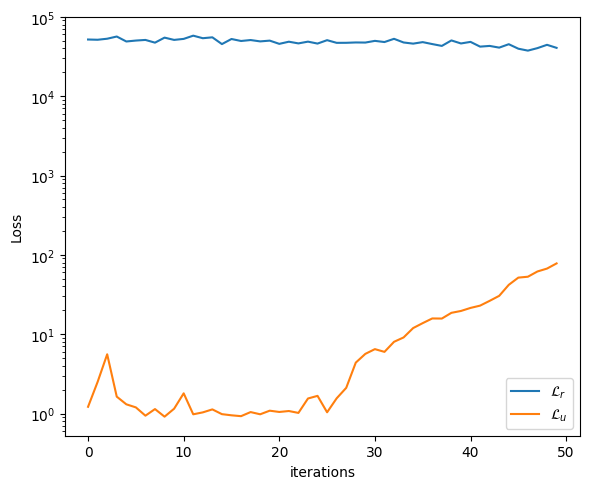

<ipython-input-9-06e93fb2e1f8>:61: RuntimeWarning: divide by zero encountered in scalar divide
  residual_l2 = np.linalg.norm(residual)/np.linalg.norm(f_right(x, a, b))


eps_l2 =  5.799241893505594
eps_c =  6.473413294840967
residual_l2 =  inf
residual_c =  453.73895


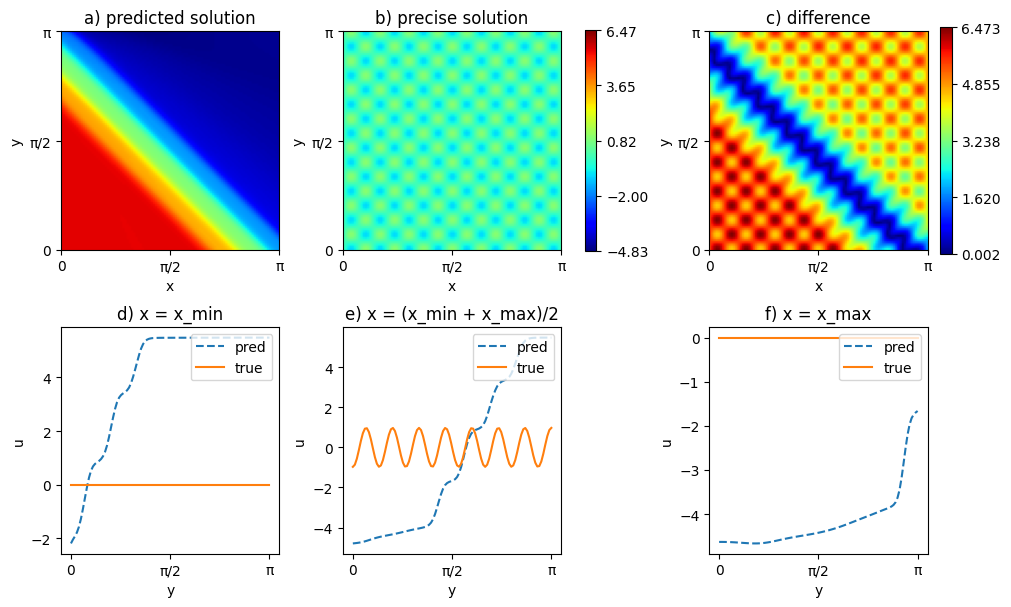

In [ ]:
#frequencies of solution
a = 15
b = 15
#domain boundaries
xmax = np.pi
ymax = np.pi
xmin = 0
ymin = 0
#number of iterations for training
N_iter = 5000
Nx_points = 100
Ny_points = 100

u, u_pr, training_frames = predict_u_with_PINN(a, b, xmin, ymin, xmax, ymax, N_iter, Nx_points, Ny_points, call_save_movie=True, fps = 3)
# file_name = "movie_" + str(a) + '_' + str(b) + ".gif"
# save_movie(training_frames, training_frames.shape[0], xmin, xmax, ymin, ymax, Nx_points, Ny_points, filename=file_name, duration=0.6)

plot_figures(u, u_pr, xmin, xmax, ymin, ymax, Nx_points, Ny_points)

In [ ]:
np.random.rand(3, 2)

array([[0.19986226, 0.61808612],
       [0.7560902 , 0.25476656],
       [0.20092007, 0.43685653]])

In [ ]:
np.random.rand(3, 2)

array([[0.12605136, 0.95341734],
       [0.76905559, 0.2644782 ],
       [0.99683105, 0.94973412]])